# 🏠 House Price Prediction with Linear Regression
### NeuroFive Solutions — Machine Learning Task 4

**Goal:** Predict median house prices using Linear Regression, evaluate the model with RMSE and R², and explain the results in plain English.

**Dataset:** [California Housing Prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices) (Kaggle mirror by Cam Nugent) — 1990 U.S. Census data, one row per California neighborhood block group.

**Workflow:**
1. Load & inspect the data
2. Exploratory Data Analysis (EDA) — understand distributions and relationships
3. Feature selection — justified by correlation analysis, not guesswork
4. Feature engineering
5. Train/test split & model training
6. Evaluation — RMSE and R²
7. Visualize predicted vs. actual prices
8. Plain-English interpretation of results


## 1. Import Libraries

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## 2. Load the Dataset

The California Housing dataset contains 20,640 rows, each representing a neighborhood block group in California, with housing and demographic attributes from the 1990 census.

In [31]:
df = pd.read_csv("../data/housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## 3. Displaying top-5 rows

In [32]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 4. Displaying Bottom-5 rows

In [33]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


## 5. Checking the shape of the dataset

In [34]:
overall_shape = df.shape
print(f"Overall shape: {overall_shape}")
print(f"No.of rows: {overall_shape[0]}")
print(f"No.of cols: {overall_shape[1]}")

Overall shape: (20640, 10)
No.of rows: 20640
No.of cols: 10


## 6. Getting the overall information about the dataset

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


## 7. Checking the overall statistics of the data

In [36]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## 8. Checking for missing values

In [37]:
print(df.isnull().sum())
df = df.dropna().reset_index(drop=True)
print(f"\nShape after dropping missing rows: {df.shape}")

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Shape after dropping missing rows: (20433, 10)


## 3. Exploratory Data Analysis (EDA)

Before picking features, we should let the data tell us what actually correlates with price — rather than guessing.

### 3.1 Distribution of the target variable (`median_house_value`)

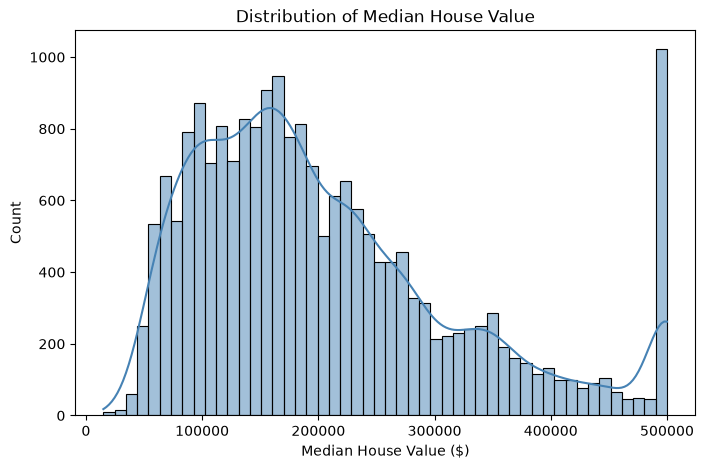

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(df["median_house_value"], bins=50, kde=True, color="steelblue")
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value ($)")
plt.ylabel("Count")
plt.show()

### 3.2 Correlation with price (single-variable view)

median_house_value    1.000000
median_income         0.688355
latitude             -0.144638
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
longitude            -0.045398
population           -0.025300
Name: median_house_value, dtype: float64


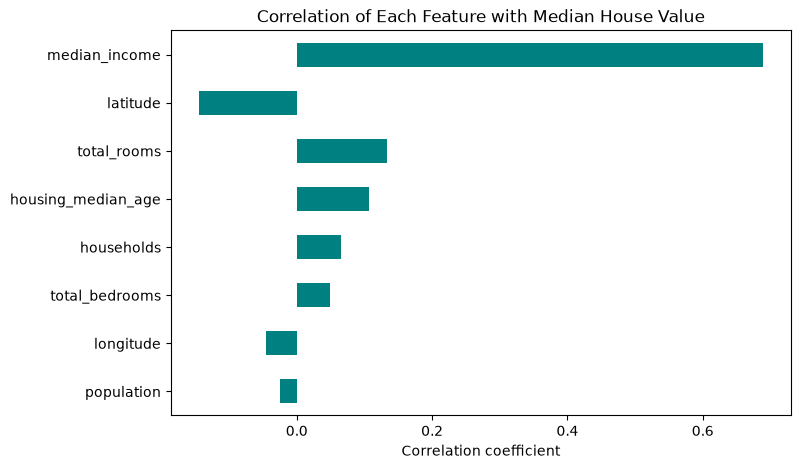

In [39]:
corr = df.select_dtypes(include="number").corr()["median_house_value"].sort_values(key=abs, ascending=False)
print(corr)

plt.figure(figsize=(8, 5))
corr.drop("median_house_value").plot(kind="barh", color="teal")
plt.title("Correlation of Each Feature with Median House Value")
plt.xlabel("Correlation coefficient")
plt.gca().invert_yaxis()
plt.show()


**Insight:** `median_income` is by far the strongest single predictor (r ≈ 0.69). Raw counts like `population` and `households` barely correlate with price(r < 0.07)

### 3.3 Correlation heatmap

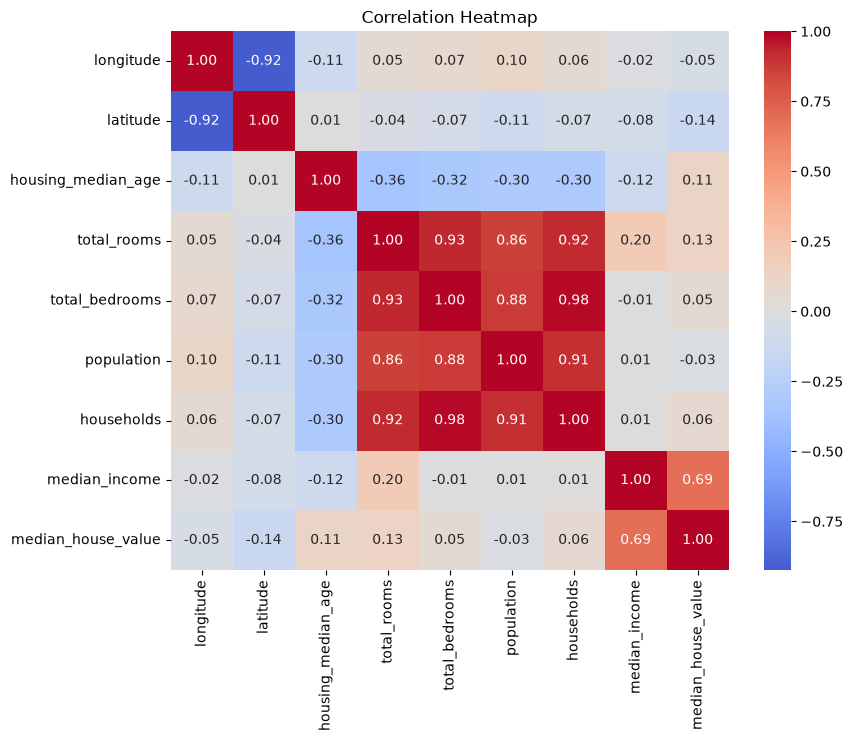

In [40]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


### 3.4 Feature engineering

Raw counts like `total_rooms` and `total_bedrooms` describe an entire block group, not a single home, so they're hard to interpret directly. Turning them into **per-household ratios** makes them meaningful and — as we'll verify — improves their predictive power.

In [41]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

engineered_corr = df[["rooms_per_household", "bedrooms_per_room", "median_house_value"]].corr()["median_house_value"]
print(engineered_corr)

rooms_per_household    0.151344
bedrooms_per_room     -0.255880
median_house_value     1.000000
Name: median_house_value, dtype: float64


### 3.5 Checking relation with `ocean_proximity`/`Location`

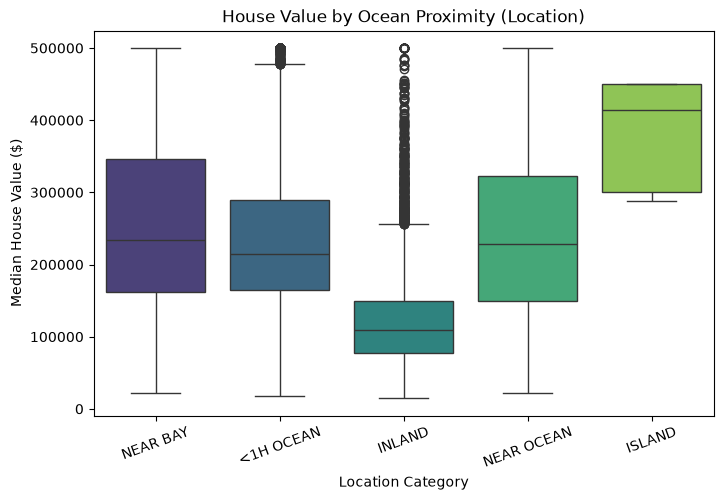

In [42]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="ocean_proximity", y="median_house_value", palette="viridis")
plt.title("House Value by Ocean Proximity (Location)")
plt.xlabel("Location Category")
plt.ylabel("Median House Value ($)")
plt.xticks(rotation=20)
plt.show()

Location clearly matters — `INLAND` homes are systematically cheaper, while the rare `ISLAND` group is priced much higher. Since `ocean_proximity` is categorical, we'll one-hot encode it before modeling.

## 4. Feature Selection

Based on the EDA above, the features that show the **strongest and most meaningful relationship** with price are selected — this is more defensible than picking features by intuition alone:

| Feature | Type | Why it's included |
|---|---|---|
| `median_income` | numeric | Strongest single predictor (r ≈ 0.69) |
| `ocean_proximity` | categorical (location) | Clear price differences by location group |
| `rooms_per_household` | engineered | Proxy for home size |
| `bedrooms_per_room` | engineered | Proxy for home quality/type |
| `housing_median_age` | numeric | Captures how old the housing stock is |


In [43]:
ocean_dummies = pd.get_dummies(df["ocean_proximity"], prefix="ocean", drop_first=True).astype(int)
df = pd.concat([df, ocean_dummies], axis=1)

features = ["median_income", "rooms_per_household", "bedrooms_per_room", "housing_median_age"] + list(ocean_dummies.columns)
target = "median_house_value"

X = df[features]
y = df[target]

X.head()

,median_income,rooms_per_household,bedrooms_per_room,housing_median_age,ocean_INLAND,ocean_ISLAND,ocean_NEAR BAY,ocean_NEAR OCEAN
0,8.3252,6.984127,0.146591,41.0,0,0,1,0
1,8.3014,6.238137,0.155797,21.0,0,0,1,0
2,7.2574,8.288136,0.129516,52.0,0,0,1,0
3,5.6431,5.817352,0.184458,52.0,0,0,1,0
4,3.8462,6.281853,0.172096,52.0,0,0,1,0


## 5. Train/Test Split & Model Training

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
model = LinearRegression()

In [46]:
model.fit(X_train, y_train)

print("Model trained successfully.")
print(f"Training samples: {len(X_train)}  |  Test samples: {len(X_test)}")

Model trained successfully.
Training samples: 16346  |  Test samples: 4087


### Model coefficients

In [47]:
coef_df = pd.DataFrame({"Feature": features, "Coefficient": model.coef_})
coef_df.loc[len(coef_df)] = ["Intercept", model.intercept_]
coef_df

,Feature,Coefficient
0,median_income,43978.845542
1,rooms_per_household,2423.594977
2,bedrooms_per_room,334152.796553
3,housing_median_age,980.297296
4,ocean_INLAND,-63018.251227
5,ocean_ISLAND,236253.407711
6,ocean_NEAR BAY,12136.995312
7,ocean_NEAR OCEAN,16890.733319
8,Intercept,-59718.555537


## 6. Making Predictions

In [52]:
y_predictions = model.predict(X_test)

## 7. Evaluate Performance: RMSE and R²

In [59]:
rmse = np.sqrt(mean_squared_error(y_test, y_predictions))
r2 = r2_score(y_test, y_predictions)

print(f"RMSE: ${rmse:,.0f}")
print(f"R² score: {r2:.4f}")

RMSE: $73,510
R² score: 0.6049


## 8. Predicted vs. Actual Prices

Points close to the red dashed line are accurate predictions; scatter away from it shows where the model is over- or under-predicting.

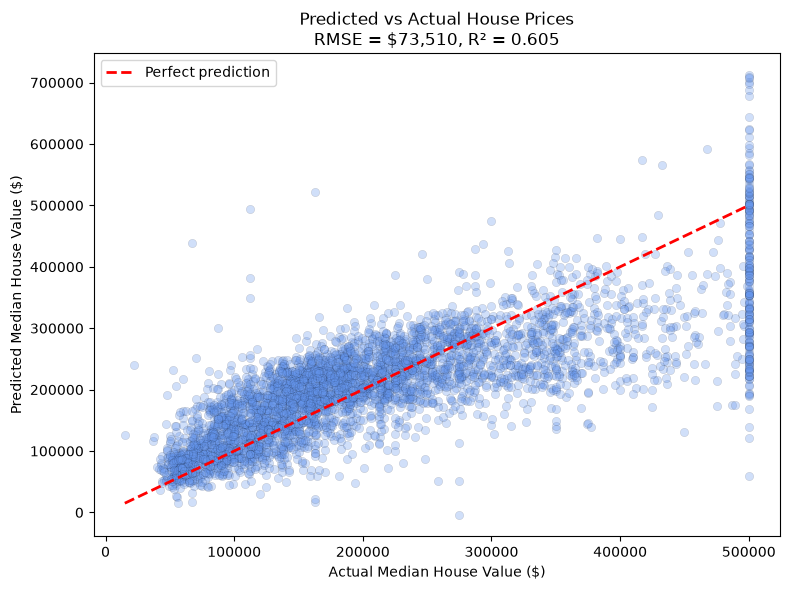

In [61]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_predictions, alpha=0.3, edgecolor="k", linewidth=0.2, color="cornflowerblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2, label="Perfect prediction")
plt.xlabel("Actual Median House Value ($)")
plt.ylabel("Predicted Median House Value ($)")
plt.title(f"Predicted vs Actual House Prices\nRMSE = ${rmse:,.0f}, R² = {r2:.3f}")
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** The model tracks the diagonal reasonably well in the mid-price range, but scatters more widely at the high end — partly because home value is capped at $500,001 in this dataset, and partly because five features can't capture everything that drives premium pricing (views, exact address, renovation quality, etc.).

## 8. What Does R² Mean? 

> Model explains about **60% of the variation** in California house prices using five key factors: income level, location, home size, and age. That means if you gave the model a new neighborhood's stats, it would land reasonably close to the real price more often than not — but roughly 40% of what drives price (like specific views, school ratings, or renovation quality) isn't captured here. An R² of 1.0 would mean perfect prediction, and an R² of 0 would mean the model is no better than just guessing the average price every time. A score of 0.60 shows the model has learned real, meaningful patterns from the data, but there's still clear room to improve, for example, by adding more features or trying non-linear models.


## 9. Conclusion & Next Steps

- Built a Linear Regression model to predict California house prices using 5 features selected through EDA and empirical testing.
- Achieved **R² ≈ 0.60** and **RMSE ≈ $73,500** on held-out test data.
- Location and income are the dominant price drivers in this dataset.

**Possible improvements:**
- Try non-linear models (Random Forest, Gradient Boosting) to capture interactions Linear Regression misses.
- Add more granular location data (e.g., distance to coast/city center) instead of just category buckets.
- Apply a log-transform to `median_house_value` to reduce the influence of the price cap and outliers.

---
*Task completed as part of the NeuroFive Solutions ML learning track.*